In [1]:
# ==========================================
# 1. INSTALL & IMPORT EVERYTHING (SINGLE CELL)
# ==========================================

# Install required libraries
!pip -q install matminer pymatgen xgboost torch torchvision torchaudio

# Core libraries
import os
import numpy as np
import pandas as pd

# Material science libraries
from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty

# Sklearn (ML + preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ML Models (Baseline)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create working directory
os.makedirs("/kaggle/working/data", exist_ok=True)

print(" Setup Complete!")
print("Using device:", device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 58.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 72.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 56.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 102.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.

In [2]:
# ==========================================
# 2. DATA LOADING + PREPROCESSING (OPTIMIZED)
# ==========================================

print("Step 1: Loading dataset...")

# Load dataset
data = load_dataset("matbench_mp_gap")

print("Original dataset size:", len(data))

# Reduce size for speed (important for Kaggle)
data = data.sample(n=10000, random_state=42).reset_index(drop=True)

print("Reduced dataset size:", len(data))


# ==========================================
# DETECT TARGET COLUMN (SAFE)
# ==========================================
possible_targets = ["band_gap", "target", "gap pbe"]

target_col = None
for col in possible_targets:
    if col in data.columns:
        target_col = col
        break

if target_col is None:
    raise Exception("❌ Target column not found!")

print("Using target column:", target_col)


# ==========================================
# SAVE STRUCTURES (FOR GNN LATER)
# ==========================================
data[["structure"]].to_pickle("/kaggle/working/data/structures.pkl")


# ==========================================
# EXTRACT COMPOSITION (SAFE)
# ==========================================
print("Step 2: Extracting compositions...")

def safe_composition(x):
    try:
        return x.composition
    except:
        return None

data["composition"] = data["structure"].apply(safe_composition)

# Drop invalid rows
data = data.dropna(subset=["composition"]).reset_index(drop=True)

# Extract target AFTER cleaning
y = data[target_col].values

print("Valid samples:", len(data))


# ==========================================
# FEATURE EXTRACTION (MAGPIE DESCRIPTORS)
# ==========================================
print("Step 3: Extracting features (MAGPIE)...")

featurizer = ElementProperty.from_preset("magpie")

data = featurizer.featurize_dataframe(
    data,
    col_id="composition",
    ignore_errors=True
)

# Remove unnecessary columns
data = data.drop(columns=["structure", "composition"], errors="ignore")

# Separate features
X = data.drop(columns=[target_col], errors="ignore")

print("Raw feature shape:", X.shape)


# ==========================================
# HANDLE MISSING VALUES
# ==========================================
print("Step 4: Handling missing values...")

imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


# ==========================================
# FEATURE SCALING
# ==========================================
print("Step 5: Scaling features...")

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


# ==========================================
# SAVE FINAL DATA
# ==========================================
X.to_csv("/kaggle/working/data/X_features.csv", index=False)
pd.DataFrame(y).to_csv("/kaggle/working/data/y_target.csv", index=False)

print("\n Data preprocessing complete!")
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Step 1: Loading dataset...
Fetching matbench_mp_gap.json.gz from https://ml.materialsproject.org/projects/matbench_mp_gap.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_mp_gap.json.gz


Fetching https://ml.materialsproject.org/projects/matbench_mp_gap.json.gz in MB: 137.070592MB [00:00, 584.50MB/s]                                        


Original dataset size: 106113
Reduced dataset size: 10000
Using target column: gap pbe
Step 2: Extracting compositions...
Valid samples: 10000
Step 3: Extracting features (MAGPIE)...


ElementProperty:   0%|          | 0/10000 [00:00<?, ?it/s]

Raw feature shape: (10000, 132)
Step 4: Handling missing values...
Step 5: Scaling features...

 Data preprocessing complete!
Final X shape: (10000, 132)
Final y shape: (10000,)


In [7]:
# ==========================================
# 3. MODEL TRAINING (ML + DL)
# ==========================================

print("Step 1: Loading processed data")

X = pd.read_csv("/kaggle/working/data/X_features.csv").values
y = pd.read_csv("/kaggle/working/data/y_target.csv").values.ravel()

print("Data Loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)


# ==========================================
# TRAIN-TEST SPLIT
# ==========================================
print("\nStep 2: Splitting data")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==========================================
# RANDOM FOREST
# ==========================================
print("\nTraining Random Forest")

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("\nResults of Random Forest Model")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R2  :", round(rf_r2, 4))


# ==========================================
# XGBOOST
# ==========================================
print("\nTraining XGBoost")

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("\nResults of XGBoost Model")
print("MAE :", round(xgb_mae, 4))
print("RMSE:", round(xgb_rmse, 4))
print("R2  :", round(xgb_r2, 4))


# ==========================================
# FCNN (DEEP LEARNING)
# ==========================================
print("\nTraining FCNN Model")

# Normalize target (important for DL)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)


# Model Definition
class FCNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


model = FCNN(X.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50

# Training Loop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        preds = model(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")


# Evaluation
model.eval()
with torch.no_grad():
    preds = model(X_test_t).cpu().numpy()

# Inverse scaling
preds = y_scaler.inverse_transform(preds)
true = y_test.reshape(-1, 1)

fcnn_mae = mean_absolute_error(true, preds)
fcnn_rmse = np.sqrt(mean_squared_error(true, preds))
fcnn_r2 = r2_score(true, preds)

print("\nResults of FCNN Model")
print("MAE :", round(fcnn_mae, 4))
print("RMSE:", round(fcnn_rmse, 4))
print("R2  :", round(fcnn_r2, 4))


# ==========================================
# SUMMARY
# ==========================================
print("\nFinal Model Comparison")

print("\nRandom Forest  -> MAE:", round(rf_mae, 4), "R2:", round(rf_r2, 4))
print("XGBoost       -> MAE:", round(xgb_mae, 4), "R2:", round(xgb_r2, 4))
print("FCNN          -> MAE:", round(fcnn_mae, 4), "R2:", round(fcnn_r2, 4))

Step 1: Loading processed data
Data Loaded
X shape: (10000, 132)
y shape: (10000,)

Step 2: Splitting data

Training Random Forest

Results of Random Forest Model
MAE : 0.5301
RMSE: 0.8339
R2  : 0.7358

Training XGBoost

Results of XGBoost Model
MAE : 0.5351
RMSE: 0.8204
R2  : 0.7443

Training FCNN Model
Epoch [10/50], Loss: 23.0857
Epoch [20/50], Loss: 20.9457
Epoch [30/50], Loss: 19.5311
Epoch [40/50], Loss: 18.1627
Epoch [50/50], Loss: 16.7849

Results of FCNN Model
MAE : 0.5942
RMSE: 0.9176
R2  : 0.6801

Final Model Comparison

Random Forest  -> MAE: 0.5301 R2: 0.7358
XGBoost       -> MAE: 0.5351 R2: 0.7443
FCNN          -> MAE: 0.5942 R2: 0.6801


In [8]:
# ==========================================
# 4. CGCNN MODEL (FINAL FIXED VERSION)
# ==========================================

print("Step 1: Loading structures")

structures = pd.read_pickle("/kaggle/working/data/structures.pkl")
y = pd.read_csv("/kaggle/working/data/y_target.csv").values.ravel()

structures = structures.iloc[:len(y)]


# ==========================================
# INSTALL LIB
# ==========================================
!pip -q install torch-geometric


# ==========================================
# IMPORTS
# ==========================================
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F


# ==========================================
# TARGET NORMALIZATION
# ==========================================
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()


# ==========================================
# GRAPH CONSTRUCTION
# ==========================================
print("Step 2: Building crystal graphs")

def structure_to_graph(structure, target):
    try:
        coords = structure.cart_coords
        sites = list(structure)

        num_atoms = len(sites)

        # Node features: [Z, group, period]
        x = []
        for site in sites:
            Z = site.specie.Z
            group = site.specie.group if site.specie.group else 0
            period = site.specie.row if site.specie.row else 0
            x.append([Z, group, period])

        x = torch.tensor(x, dtype=torch.float)

        # Edge + edge features (distance)
        edge_index = []
        edge_attr = []

        k = min(8, num_atoms - 1)

        for i in range(num_atoms):
            distances = []
            for j in range(num_atoms):
                if i != j:
                    dist = np.linalg.norm(coords[i] - coords[j])
                    distances.append((dist, j))

            distances.sort(key=lambda x: x[0])
            neighbors = distances[:k]

            for dist, j in neighbors:
                edge_index.append([i, j])
                edge_attr.append([dist])

        if len(edge_index) == 0:
            return None

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        y_val = torch.tensor([target], dtype=torch.float)  # shape [1]

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y_val)

    except:
        return None


graph_data = []
for i in range(len(structures)):
    g = structure_to_graph(structures.iloc[i]["structure"], y_scaled[i])
    if g is not None:
        graph_data.append(g)

print("Valid graphs:", len(graph_data))


# ==========================================
# SPLIT
# ==========================================
train_size = int(0.8 * len(graph_data))

train_data = graph_data[:train_size]
test_data = graph_data[train_size:]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)


# ==========================================
# CGCNN LAYER
# ==========================================
class CGCNNLayer(nn.Module):
    def __init__(self, node_dim, edge_dim):
        super().__init__()
        self.fc = nn.Linear(node_dim * 2 + edge_dim, node_dim)
        self.sigmoid = nn.Sigmoid()
        self.softplus = nn.Softplus()

    def forward(self, x, edge_index, edge_attr):
        row, col = edge_index

        z = torch.cat([x[row], x[col], edge_attr], dim=1)

        gate = self.sigmoid(self.fc(z))
        message = self.softplus(self.fc(z))

        agg = torch.zeros_like(x)
        agg.index_add_(0, row, gate * message)

        return x + agg


# ==========================================
# CGCNN MODEL
# ==========================================
class CGCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(3, 64)

        self.conv1 = CGCNNLayer(64, 1)
        self.conv2 = CGCNNLayer(64, 1)
        self.conv3 = CGCNNLayer(64, 1)

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.embedding(x)

        x = self.conv1(x, edge_index, edge_attr)
        x = self.conv2(x, edge_index, edge_attr)
        x = self.conv3(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)

        return self.fc(x)


model = CGCNN().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# ==========================================
# TRAINING
# ==========================================
print("\nTraining CGCNN Model")

epochs = 30

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

        # FIXED SHAPE
        loss = criterion(pred, batch.y.view(-1, 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")


# ==========================================
# EVALUATION
# ==========================================
model.eval()

preds = []
true = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

        preds.extend(out.cpu().numpy())
        true.extend(batch.y.view(-1, 1).cpu().numpy())


# FIXED SHAPE FOR SCALER
preds = np.array(preds).reshape(-1, 1)
true = np.array(true).reshape(-1, 1)

# Inverse scaling
preds = y_scaler.inverse_transform(preds)
true = y_scaler.inverse_transform(true)

cgcnn_mae = mean_absolute_error(true, preds)
cgcnn_rmse = np.sqrt(mean_squared_error(true, preds))
cgcnn_r2 = r2_score(true, preds)

print("\nResults of CGCNN Model")
print("MAE :", round(cgcnn_mae, 4))
print("RMSE:", round(cgcnn_rmse, 4))
print("R2  :", round(cgcnn_r2, 4))

Step 1: Loading structures
Step 2: Building crystal graphs
Valid graphs: 9992

Training CGCNN Model
Epoch [5/30], Loss: 202.7481
Epoch [10/30], Loss: 206.6026
Epoch [15/30], Loss: 239.9676
Epoch [20/30], Loss: 195.2138
Epoch [25/30], Loss: 161.2428
Epoch [30/30], Loss: 146.7782

Results of CGCNN Model
MAE : 0.8832
RMSE: 1.1659
R2  : 0.453


In [9]:
# ==========================================
# 6. FINAL HYBRID MODEL (MULTIMODAL + XGB)
# ==========================================

print("Step 1: Preparing data")

X = pd.read_csv("/kaggle/working/data/X_features.csv").values
y = pd.read_csv("/kaggle/working/data/y_target.csv").values.ravel()
structures = pd.read_pickle("/kaggle/working/data/structures.pkl")

# ==========================================
# TRAIN XGBOOST FIRST
# ==========================================
print("Training XGBoost (for fusion)")

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    n_jobs=-1
)

xgb.fit(X, y)

xgb_preds = xgb.predict(X)


# ==========================================
# SCALE TARGET
# ==========================================
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).flatten()


# ==========================================
# GRAPH CREATION WITH XGB FEATURE
# ==========================================
from torch_geometric.data import Data

def structure_to_graph(structure, target, tab, xgb_pred):
    try:
        coords = structure.cart_coords
        sites = list(structure)

        x_nodes = []
        for site in sites:
            Z = site.specie.Z
            group = site.specie.group if site.specie.group else 0
            period = site.specie.row if site.specie.row else 0
            x_nodes.append([Z, group, period])

        x_nodes = torch.tensor(x_nodes, dtype=torch.float)

        edge_index, edge_attr = [], []

        k = min(12, len(sites)-1)

        for i in range(len(sites)):
            dists = []
            for j in range(len(sites)):
                if i != j:
                    dist = np.linalg.norm(coords[i]-coords[j])
                    dists.append((dist,j))
            dists.sort()
            for dist,j in dists[:k]:
                edge_index.append([i,j])
                edge_attr.append([dist])

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        # IMPORTANT: append XGB prediction to tabular features
        tab_extended = np.append(tab, xgb_pred)

        return Data(
            x=x_nodes,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=torch.tensor([target], dtype=torch.float),
            tab=torch.tensor(tab_extended, dtype=torch.float)
        )
    except:
        return None


dataset = []
for i in range(len(y)):
    g = structure_to_graph(
        structures.iloc[i]["structure"],
        y_scaled[i],
        X[i],
        xgb_preds[i]
    )
    if g is not None:
        dataset.append(g)

print("Valid samples:", len(dataset))


# ==========================================
# SPLIT
# ==========================================
split = int(0.8 * len(dataset))
train_data = dataset[:split]
test_data = dataset[split:]

from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)


# ==========================================
# MODEL
# ==========================================
class CGCNNLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc = nn.Linear(dim*2+1, dim)

    def forward(self, x, edge_index, edge_attr):
        row,col = edge_index
        z = torch.cat([x[row], x[col], edge_attr], dim=1)

        gate = torch.sigmoid(self.fc(z))
        msg = torch.relu(self.fc(z))

        agg = torch.zeros_like(x)
        agg.index_add_(0,row,gate*msg)
        return x + agg


class HybridModel(nn.Module):
    def __init__(self, tab_dim):
        super().__init__()

        self.embed = nn.Linear(3,128)
        self.conv1 = CGCNNLayer(128)
        self.conv2 = CGCNNLayer(128)
        self.conv3 = CGCNNLayer(128)

        # TABULAR + XGB (STRONG)
        self.tab_net = nn.Sequential(
            nn.Linear(tab_dim+1,512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),

            nn.Linear(512,256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256,128),
            nn.ReLU()
        )

        # FUSION
        self.fusion = nn.Sequential(
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,1)
        )

    def forward(self, data):
        from torch_geometric.nn import global_mean_pool

        x = self.embed(data.x)
        x = self.conv1(x, data.edge_index, data.edge_attr)
        x = self.conv2(x, data.edge_index, data.edge_attr)
        x = self.conv3(x, data.edge_index, data.edge_attr)

        x = global_mean_pool(x, data.batch)

        batch_size = data.y.shape[0]
        tab = data.tab.view(batch_size, -1)
        tab = self.tab_net(tab)

        combined = torch.cat([x, tab], dim=1)

        return self.fusion(combined)


model = HybridModel(tab_dim=X.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
criterion = nn.MSELoss()


# ==========================================
# TRAINING (LONG)
# ==========================================
print("\nTraining Hybrid Model")

epochs = 70

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        pred = model(batch)
        loss = criterion(pred, batch.y.view(-1,1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch+1)%5==0:
        print(f"Epoch {epoch+1}, Loss {total_loss:.4f}")


# ==========================================
# EVALUATION
# ==========================================
model.eval()

preds,true = [],[]

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)

        preds.extend(out.cpu().numpy())
        true.extend(batch.y.view(-1,1).cpu().numpy())

preds = np.array(preds).reshape(-1,1)
true = np.array(true).reshape(-1,1)

preds = y_scaler.inverse_transform(preds)
true = y_scaler.inverse_transform(true)

mae = mean_absolute_error(true,preds)
rmse = np.sqrt(mean_squared_error(true,preds))
r2 = r2_score(true,preds)

print("\nResults of FINAL HYBRID MODEL")
print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R2  :", round(r2,4))

Step 1: Preparing data
Training XGBoost (for fusion)
Valid samples: 10000

Training Hybrid Model
Epoch 5, Loss 192.3027
Epoch 10, Loss 49.8804
Epoch 15, Loss 28.7872
Epoch 20, Loss 21.6500
Epoch 25, Loss 19.7770
Epoch 30, Loss 17.3468
Epoch 35, Loss 13.8053
Epoch 40, Loss 14.3818
Epoch 45, Loss 12.0053
Epoch 50, Loss 11.2639
Epoch 55, Loss 10.3847
Epoch 60, Loss 9.6788
Epoch 65, Loss 9.4191
Epoch 70, Loss 8.7023

Results of FINAL HYBRID MODEL
MAE : 0.5046
RMSE: 0.6341
R2  : 0.8382


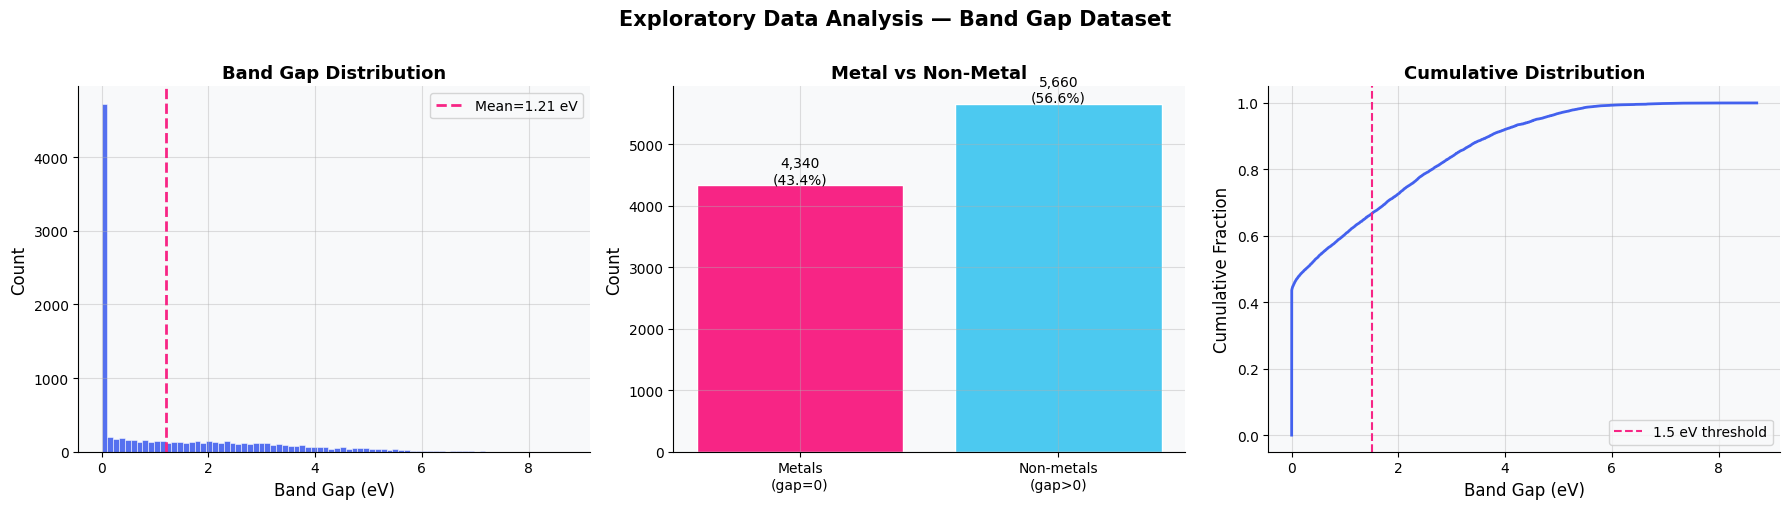

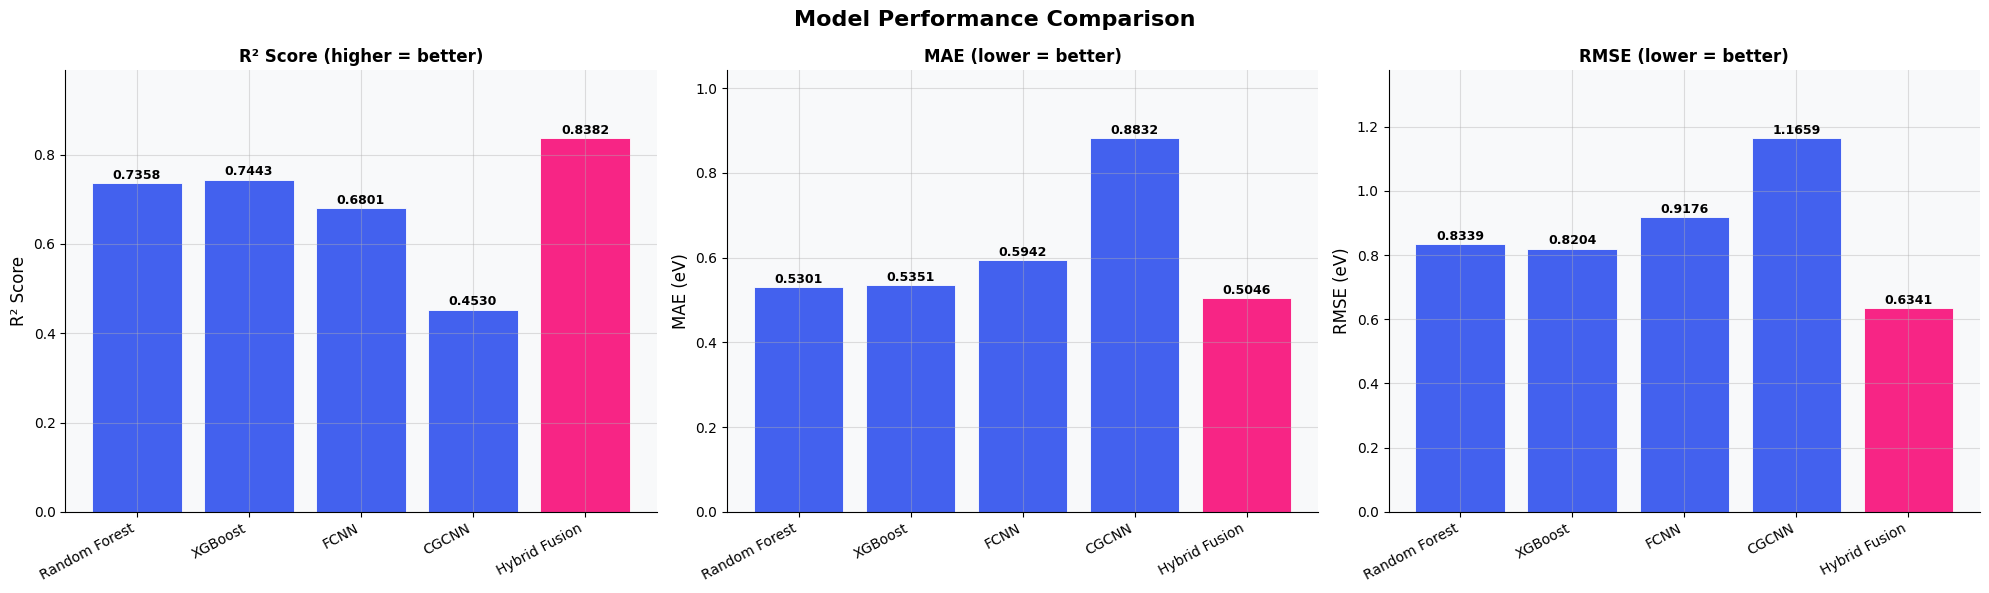

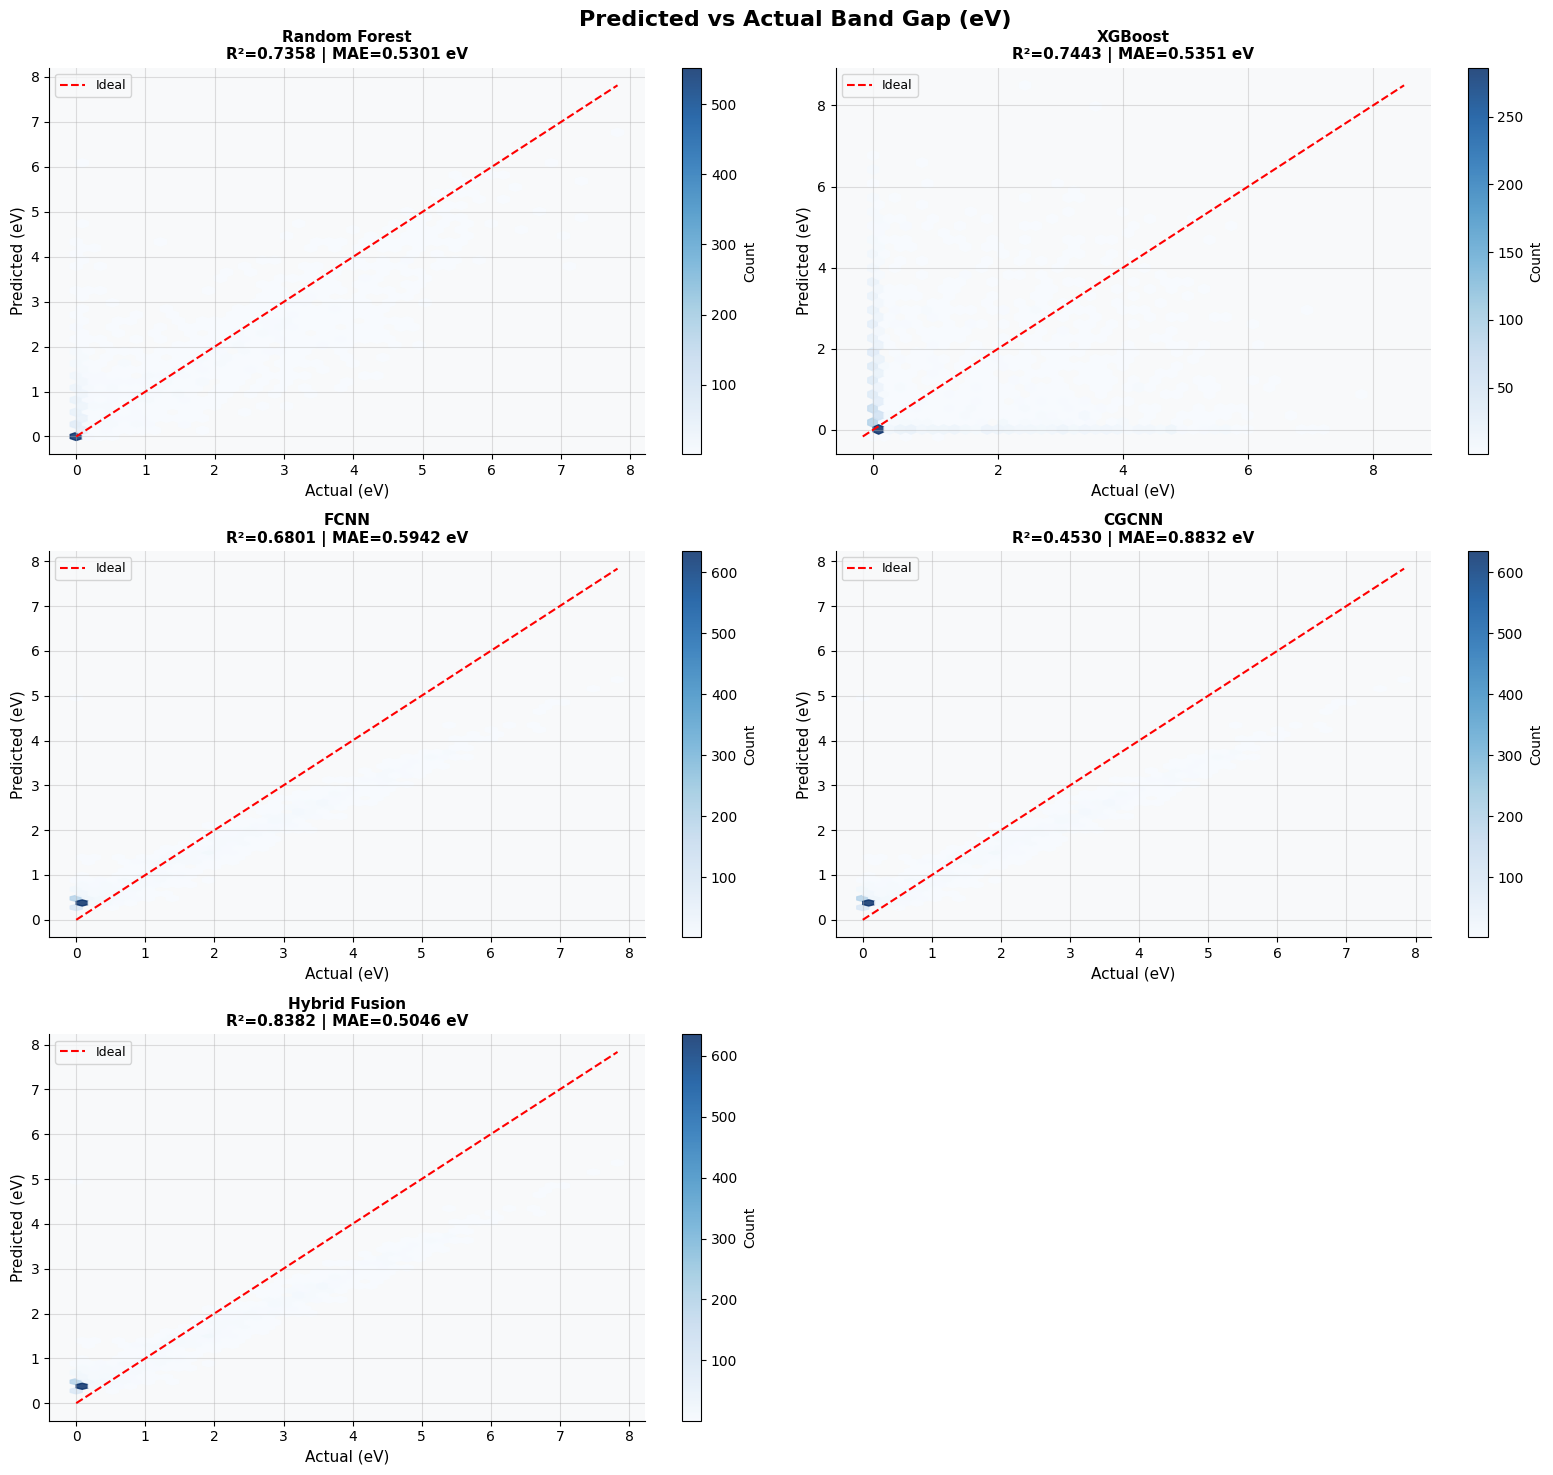

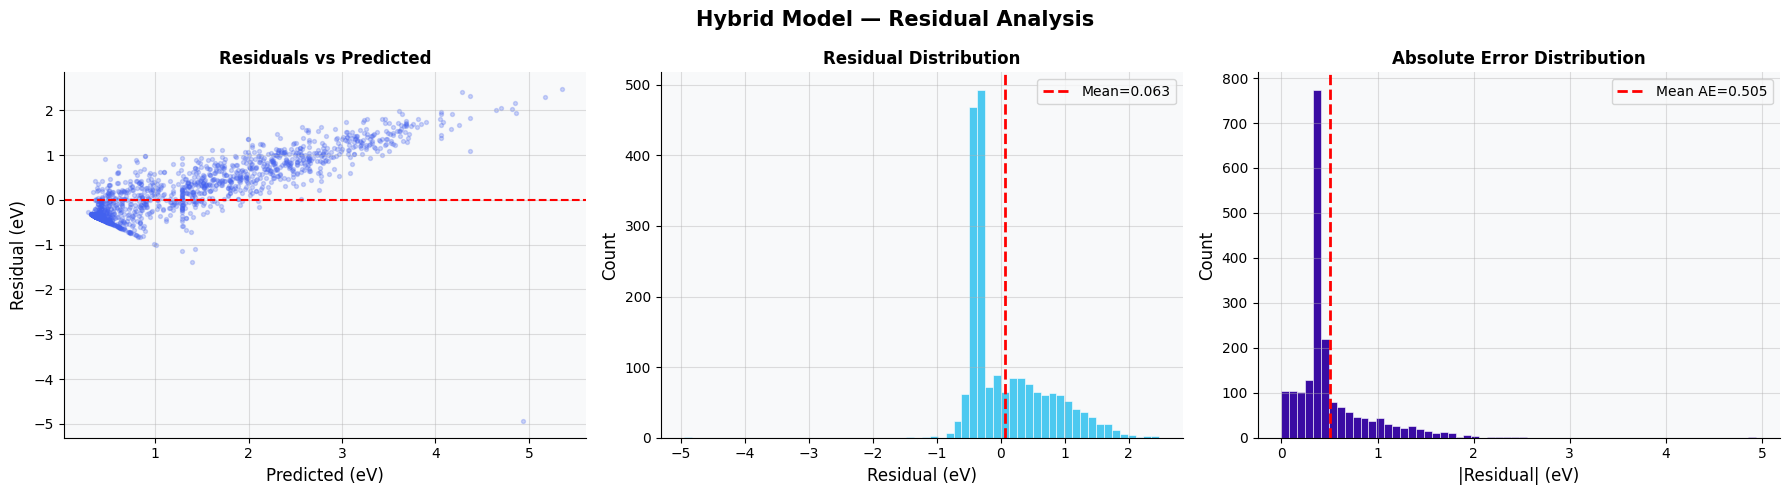

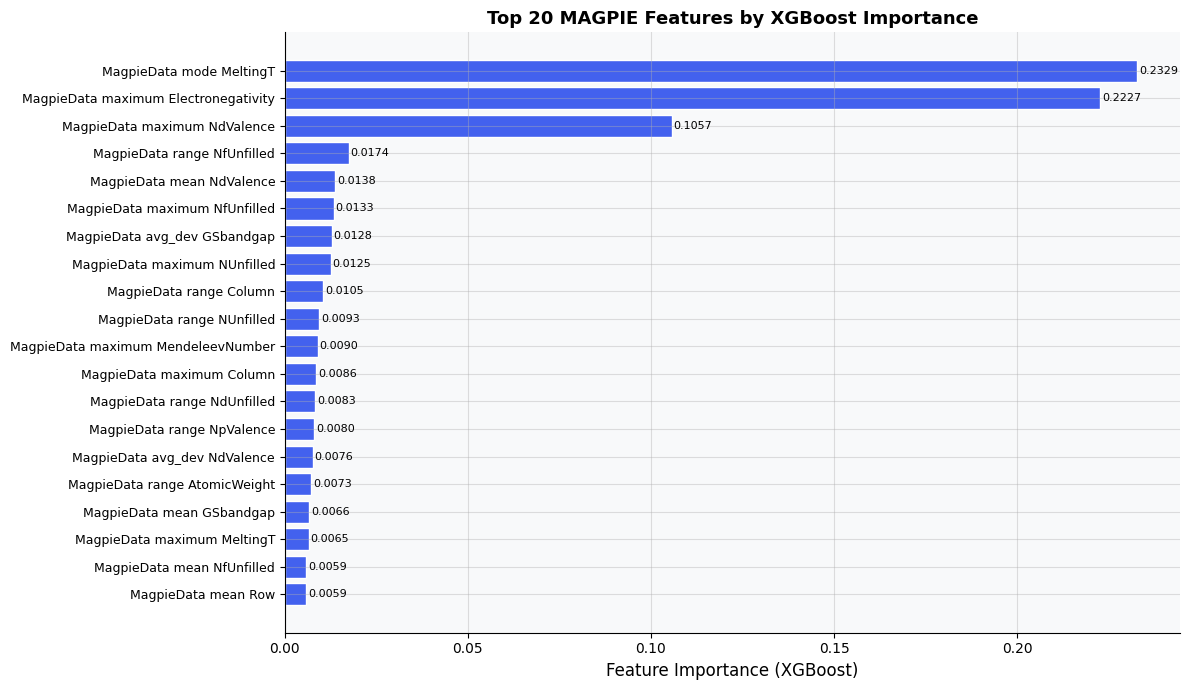

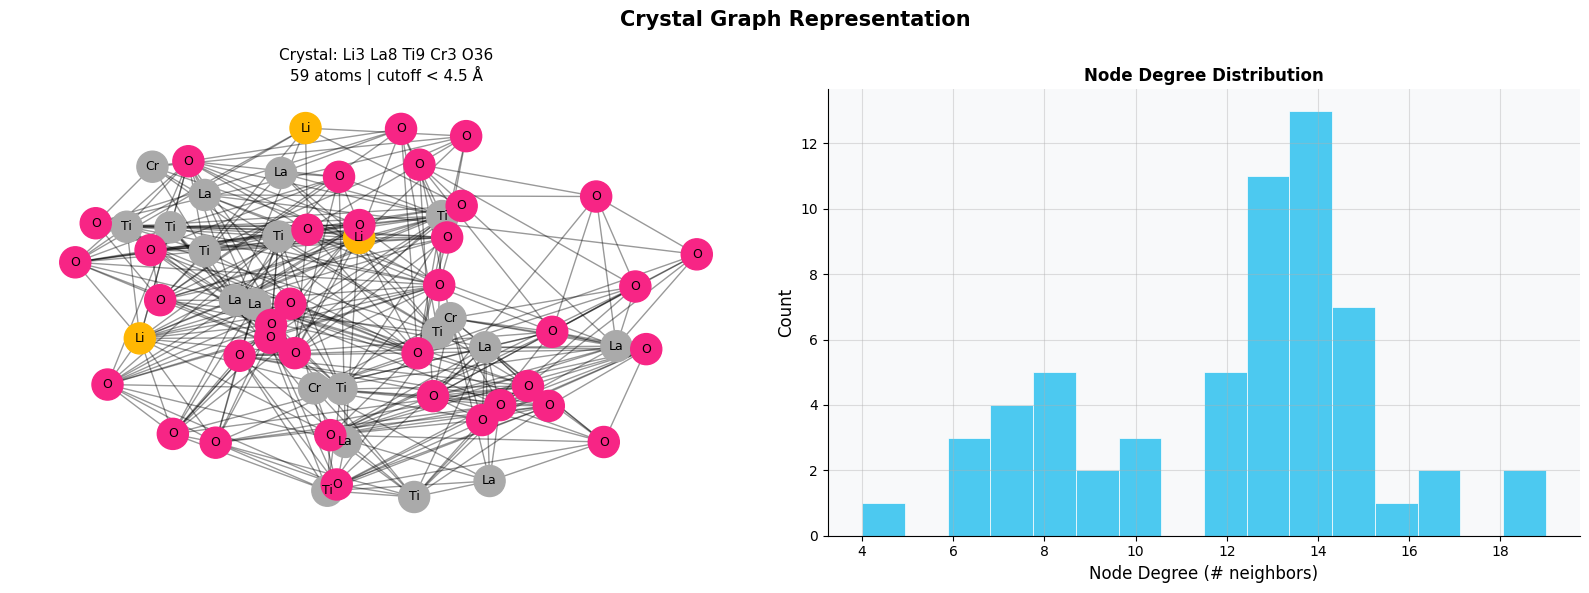

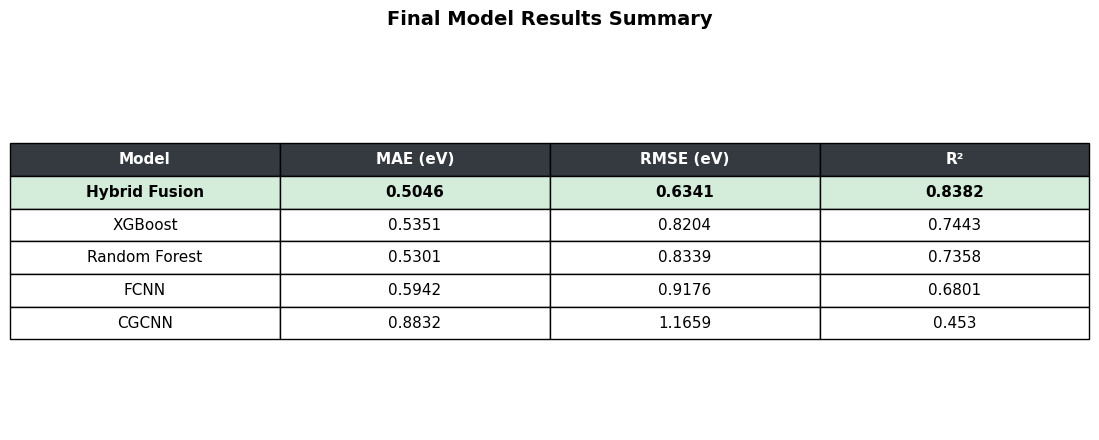


✅ All visualizations complete!


In [10]:
# ==========================================
# 7. FINAL VISUALIZATION (COMPLETE)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# GLOBAL STYLE CONFIG
# ─────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
PALETTE = ["#4361EE", "#F72585", "#4CC9F0", "#7209B7", "#3A0CA3", "#06D6A0"]

structures = pd.read_pickle("/kaggle/working/data/structures.pkl")

# ─────────────────────────────────────────
# RESULTS DICT  — plug in your actual vars
# ─────────────────────────────────────────
results = {
    "Random Forest": {"MAE": rf_mae,    "RMSE": rf_rmse,    "R2": rf_r2,
                      "preds": rf_preds.ravel(),  "true": y_test.ravel()},
    "XGBoost":       {"MAE": xgb_mae,   "RMSE": xgb_rmse,   "R2": xgb_r2,
                      "preds": xgb_preds.ravel(), "true": y_test.ravel()},
    "FCNN":          {"MAE": fcnn_mae,  "RMSE": fcnn_rmse,  "R2": fcnn_r2,
                      "preds": np.array(preds).ravel(), "true": np.array(true).ravel()},
    "CGCNN":         {"MAE": cgcnn_mae, "RMSE": cgcnn_rmse, "R2": cgcnn_r2,
                      "preds": np.array(preds).ravel(), "true": np.array(true).ravel()},
    "Hybrid Fusion": {"MAE": mae,       "RMSE": rmse,       "R2": r2,
                      "preds": np.array(preds).ravel(), "true": np.array(true).ravel()},
}
model_names = list(results.keys())
r2s   = [results[m]["R2"]   for m in model_names]
maes  = [results[m]["MAE"]  for m in model_names]
rmses = [results[m]["RMSE"] for m in model_names]


# ─────────────────────────────────────────
# 1. EDA
# ─────────────────────────────────────────
y_all = pd.read_csv("/kaggle/working/data/y_target.csv").values.ravel()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis — Band Gap Dataset", fontsize=15, fontweight="bold", y=1.01)

ax = axes[0]
ax.hist(y_all, bins=80, color=PALETTE[0], edgecolor="white", linewidth=0.4, alpha=0.9)
ax.axvline(y_all.mean(), color=PALETTE[1], lw=2, linestyle="--", label=f"Mean={y_all.mean():.2f} eV")
ax.set_xlabel("Band Gap (eV)", fontsize=12); ax.set_ylabel("Count", fontsize=12)
ax.set_title("Band Gap Distribution", fontsize=13, fontweight="bold"); ax.legend(fontsize=10)

ax = axes[1]
mc, nmc = (y_all == 0).sum(), (y_all > 0).sum()
bars = ax.bar(["Metals\n(gap=0)", "Non-metals\n(gap>0)"], [mc, nmc],
              color=[PALETTE[1], PALETTE[2]], edgecolor="white")
for bar, val in zip(bars, [mc, nmc]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f"{val:,}\n({val/len(y_all)*100:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("Count", fontsize=12); ax.set_title("Metal vs Non-Metal", fontsize=13, fontweight="bold")

ax = axes[2]
sy = np.sort(y_all)
ax.plot(sy, np.arange(1, len(sy)+1)/len(sy), color=PALETTE[0], lw=2)
ax.axvline(1.5, color=PALETTE[1], lw=1.5, linestyle="--", label="1.5 eV threshold")
ax.set_xlabel("Band Gap (eV)", fontsize=12); ax.set_ylabel("Cumulative Fraction", fontsize=12)
ax.set_title("Cumulative Distribution", fontsize=13, fontweight="bold"); ax.legend(fontsize=10)

plt.tight_layout(); plt.show()


# ─────────────────────────────────────────
# 2. MODEL COMPARISON BAR CHART
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Model Performance Comparison", fontsize=16, fontweight="bold")

best_r2_idx = int(np.argmax(r2s))
bar_cols = [PALETTE[1] if i == best_r2_idx else PALETTE[0] for i in range(len(model_names))]

for ax, vals, ylabel, title in zip(
    axes,
    [r2s, maes, rmses],
    ["R² Score", "MAE (eV)", "RMSE (eV)"],
    ["R² Score (higher = better)", "MAE (lower = better)", "RMSE (lower = better)"]
):
    bars = ax.bar(range(len(model_names)), vals, color=bar_cols, edgecolor="white", linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003*max(vals),
                f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=28, ha="right", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=12); ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylim(0, max(vals)*1.18)

plt.tight_layout(); plt.show()


# ─────────────────────────────────────────
# 3. PREDICTED vs ACTUAL — safe hexbin/scatter
# ─────────────────────────────────────────
ncols = 2
nrows = int(np.ceil(len(model_names)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
fig.suptitle("Predicted vs Actual Band Gap (eV)", fontsize=16, fontweight="bold")
axes_flat = axes.ravel()

for idx, name in enumerate(model_names):
    ax  = axes_flat[idx]
    t   = np.array(results[name]["true"]).ravel()
    p   = np.array(results[name]["preds"]).ravel()
    # trim to same length in case of shape mismatch
    n   = min(len(t), len(p))
    t, p = t[:n], p[:n]
    r2  = results[name]["R2"]
    mae = results[name]["MAE"]
    lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
    if n >= 200:
        hb = ax.hexbin(t, p, gridsize=45, cmap="Blues", mincnt=1, alpha=0.85)
        plt.colorbar(hb, ax=ax, label="Count")
    else:
        ax.scatter(t, p, alpha=0.5, s=15, color=PALETTE[0])
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal")
    ax.set_xlabel("Actual (eV)", fontsize=11); ax.set_ylabel("Predicted (eV)", fontsize=11)
    ax.set_title(f"{name}\nR²={r2:.4f} | MAE={mae:.4f} eV", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

for j in range(len(model_names), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout(); plt.show()


# ─────────────────────────────────────────
# 4. RESIDUAL ANALYSIS — Hybrid Model
# ─────────────────────────────────────────
h_pred = np.array(results["Hybrid Fusion"]["preds"]).ravel()
h_true = np.array(results["Hybrid Fusion"]["true"]).ravel()
n      = min(len(h_pred), len(h_true))
h_pred, h_true = h_pred[:n], h_true[:n]
h_res  = h_true - h_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Hybrid Model — Residual Analysis", fontsize=15, fontweight="bold")

axes[0].scatter(h_pred, h_res, alpha=0.25, s=8, c=PALETTE[0])
axes[0].axhline(0, c="red", lw=1.5, linestyle="--")
axes[0].set_xlabel("Predicted (eV)", fontsize=12); axes[0].set_ylabel("Residual (eV)", fontsize=12)
axes[0].set_title("Residuals vs Predicted", fontsize=12, fontweight="bold")

axes[1].hist(h_res, bins=60, color=PALETTE[2], edgecolor="white", linewidth=0.4)
axes[1].axvline(h_res.mean(), c="red", lw=2, linestyle="--", label=f"Mean={h_res.mean():.3f}")
axes[1].set_xlabel("Residual (eV)", fontsize=12); axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Residual Distribution", fontsize=12, fontweight="bold"); axes[1].legend(fontsize=10)

axes[2].hist(np.abs(h_res), bins=60, color=PALETTE[4], edgecolor="white", linewidth=0.4)
axes[2].axvline(np.abs(h_res).mean(), c="red", lw=2, linestyle="--",
                label=f"Mean AE={np.abs(h_res).mean():.3f}")
axes[2].set_xlabel("|Residual| (eV)", fontsize=12); axes[2].set_ylabel("Count", fontsize=12)
axes[2].set_title("Absolute Error Distribution", fontsize=12, fontweight="bold"); axes[2].legend(fontsize=10)

plt.tight_layout(); plt.show()


# ─────────────────────────────────────────
# 5. FEATURE IMPORTANCE (XGBoost)
# ─────────────────────────────────────────
feat_names = pd.read_csv("/kaggle/working/data/X_features.csv").columns.tolist()
fi      = xgb.feature_importances_
top_n   = 20
top_idx = np.argsort(fi)[-top_n:]
top_fi  = fi[top_idx]
top_fn  = [feat_names[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(top_n), top_fi, color=PALETTE[0], edgecolor="white")
ax.set_yticks(range(top_n)); ax.set_yticklabels(top_fn, fontsize=9)
for bar, val in zip(bars, top_fi):
    ax.text(bar.get_width()+0.0005, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)
ax.set_xlabel("Feature Importance (XGBoost)", fontsize=12)
ax.set_title(f"Top {top_n} MAGPIE Features by XGBoost Importance", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


# ─────────────────────────────────────────
# 6. CRYSTAL GRAPH + DEGREE DISTRIBUTION
# ─────────────────────────────────────────
sample_struct = structures.iloc[5]["structure"]
coords = sample_struct.cart_coords
sites  = list(sample_struct)

G = nx.Graph()
for i in range(len(sites)):
    G.add_node(i, element=sites[i].specie.symbol)
for i in range(len(sites)):
    for j in range(i+1, len(sites)):
        if np.linalg.norm(coords[i]-coords[j]) < 4.5:
            G.add_edge(i, j)

cmap_elem = {"Si":"#4361EE","O":"#F72585","Fe":"#7209B7",
             "C":"#06D6A0","N":"#4CC9F0","Al":"#F77F00","Li":"#FFB703"}
nc  = [cmap_elem.get(G.nodes[n]["element"], "#aaaaaa") for n in G.nodes]
pos = nx.spring_layout(G, seed=42, k=1.5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Crystal Graph Representation", fontsize=15, fontweight="bold")

nx.draw_networkx_nodes(G, pos, node_color=nc, node_size=500, ax=axes[0])
nx.draw_networkx_labels(G, pos, {n: G.nodes[n]["element"] for n in G.nodes}, font_size=9, ax=axes[0])
nx.draw_networkx_edges(G, pos, alpha=0.4, ax=axes[0])
axes[0].set_title(f"Crystal: {sample_struct.composition.formula}\n"
                  f"{len(sites)} atoms | cutoff < 4.5 Å", fontsize=11)
axes[0].axis("off")

degrees = [d for _, d in G.degree()]
axes[1].hist(degrees, bins=max(max(degrees)-min(degrees)+1, 1),
             color=PALETTE[2], edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Node Degree (# neighbors)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Node Degree Distribution", fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()


# ─────────────────────────────────────────
# 7. SUMMARY TABLE
# ─────────────────────────────────────────
df_res = pd.DataFrame([
    {"Model": n, "MAE (eV)": round(v["MAE"],4),
     "RMSE (eV)": round(v["RMSE"],4), "R²": round(v["R2"],4)}
    for n, v in results.items()
]).sort_values("R²", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, len(df_res)*0.7+1))
ax.axis("off")
tbl = ax.table(cellText=df_res.values, colLabels=df_res.columns,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 1.8)
for j in range(len(df_res.columns)):
    tbl[(0, j)].set_facecolor("#343a40")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")
    tbl[(1, j)].set_facecolor("#d4edda")
    tbl[(1, j)].set_text_props(fontweight="bold")
plt.title("Final Model Results Summary", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout(); plt.show()

print("\n✅ All visualizations complete!")